<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Algopro/Algopro%20MultiHeadAttention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!gdown 1d7qwMrVyLzc7S-45twjS5iZMe9d5BYyu

Downloading...
From: https://drive.google.com/uc?id=1d7qwMrVyLzc7S-45twjS5iZMe9d5BYyu
To: c:\Balint\AI\Anyagok\Jegyzetrepo\AI-Jegyzetek\Algopro\dual_stream.jsonl

  0%|          | 0.00/924k [00:00<?, ?B/s]
 57%|█████▋    | 524k/924k [00:00<00:00, 2.82MB/s]
100%|██████████| 924k/924k [00:00<00:00, 3.11MB/s]
100%|██████████| 924k/924k [00:00<00:00, 3.05MB/s]


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import json
from collections import Counter

DATA_PATH = "dual_stream.jsonl"

data = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        text = obj["text"]
        target = obj["target"]

        data.append((text, target))

random.shuffle(data)

print(f"Loaded {len(data)} examples")

print(f"\nSample (input -> target) pairs:")
for inp, target in data[:5]:
    preview = inp if len(inp) <= 150 else inp[:147] + "..."
    print(f"  {preview}\n    -> {target}\n")

lengths = [len(inp) for inp, _ in data]
print(f"Input length: min: {min(lengths)}, avg: {sum(lengths)/len(lengths):.1f}, max: {max(lengths)}")

Loaded 15000 examples

Sample (input -> target) pairs:
  AAA | XXY
    -> 112

  AABB | YXXY
    -> 2134

  BBAAABBBABBB | YXYYXXXYXXYX
    -> 432213341343

  AABBAAAAAAAABBBAABA | XYXXXYXXXXXYXXYXXXX
    -> 1233121111123341131

  ABAABBAAA | YYXXYXYYX
    -> 241143221

Input length: min: 5, avg: 24.0, max: 43


In [5]:
from collections import Counter
input_char_counts = Counter()
output_char_counts = Counter()
for inp, target in data:
    input_char_counts.update(inp)
    output_char_counts.update(target)

# keep all chars that appear at least 2 times
input_chars = sorted(c for c, n in input_char_counts.items() if n >= 2)
output_chars = sorted(output_char_counts.keys())

PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"

input_vocab = [PAD, UNK] + input_chars
output_vocab = [PAD, SOS, EOS] + output_chars

input_stoi = {c: i for i, c in enumerate(input_vocab)}
input_itos = {i: c for i, c in enumerate(input_vocab)}
output_stoi = {c: i for i, c in enumerate(output_vocab)}
output_itos = {i: c for i, c in enumerate(output_vocab)}

print(f"Input vocab size:  {len(input_vocab)}")
print(f"Output vocab size: {len(output_vocab)}")

# cap input length at 99th percentile to avoid outliers bloating padding
sorted_lens = sorted(len(inp) for inp, _ in data)
MAX_INPUT_LEN = sorted_lens[int(0.99 * len(sorted_lens))]
MAX_OUTPUT_LEN = max(len(tgt) for _, tgt in data) + 2  # +SOS +EOS
print(f"Max input length (99th pct): {MAX_INPUT_LEN}")
print(f"Max output length: {MAX_OUTPUT_LEN}")

# drop examples above the cap so we don't truncate actual dates
kept = [(inp, tgt) for inp, tgt in data if len(inp) <= MAX_INPUT_LEN]
print(f"Keeping {len(kept)}/{len(data)} examples after length cap")
data = kept

def encode_input(s):
    ids = [input_stoi.get(c, input_stoi[UNK]) for c in s]
    ids += [input_stoi[PAD]] * (MAX_INPUT_LEN - len(ids))
    return ids

def encode_output(s):
    ids = [output_stoi[SOS]] + [output_stoi[c] for c in s] + [output_stoi[EOS]]
    ids += [output_stoi[PAD]] * (MAX_OUTPUT_LEN - len(ids))
    return ids

class DateDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        inp, tgt = self.pairs[idx]
        return (torch.tensor(encode_input(inp), dtype=torch.long),
                torch.tensor(encode_output(tgt), dtype=torch.long),
                inp, tgt)

split = int(0.9 * len(data))
train_data = data[:split]
test_data = data[split:]

train_loader = DataLoader(DateDataset(train_data), batch_size=64, shuffle=True,
                          collate_fn=lambda b: (torch.stack([x[0] for x in b]),
                                                torch.stack([x[1] for x in b]),
                                                [x[2] for x in b],
                                                [x[3] for x in b]))
test_loader = DataLoader(DateDataset(test_data), batch_size=64,
                         collate_fn=lambda b: (torch.stack([x[0] for x in b]),
                                               torch.stack([x[1] for x in b]),
                                               [x[2] for x in b],
                                               [x[3] for x in b]))

print(f"\nTrain size: {len(train_data)}, Test size: {len(test_data)}")

Input vocab size:  8
Output vocab size: 7
Max input length (99th pct): 43
Max output length: 22
Keeping 15000/15000 examples after length cap

Train size: 13500, Test size: 1500


In [6]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch, n_queries, d_k)       - queries
    K: (batch, n_keys, d_k)          - keys
    V: (batch, n_keys, d_v)          - values
    mask: (batch, n_queries, n_keys) - 1 where valid, 0 where padded

    Returns:
      output:     (batch, n_queries, d_v)
      attn_weights: (batch, n_queries, n_keys)
    """
    d_k = Q.size(-1)

    # step 1: compute raw scores Q @ K^T
    # shape: (batch, n_queries, n_keys)
    scores = Q @ K.transpose(-1, -2)

    # step 2: scale by sqrt(d_k) for softmax
    scores = scores / d_k ** 0.5

    # step 3: apply mask (set padded positions to -inf so softmax ignores them)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    # step 4: softmax over the keys dimension -> attention weights
    attn_weights = torch.softmax(scores, -1)

    # step 5: weighted sum of values
    output = attn_weights @ V

    return output, attn_weights


# check on tiny inputs
Q_test = torch.tensor([[[1.0, 0.0], [0.0, 1.0]]]) # 2 queries
K_test = torch.tensor([[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]]) # 3 keys
V_test = torch.tensor([[[10.0, 0.0], [0.0, 20.0], [5.0, 5.0]]]) # 3 values

out, w = scaled_dot_product_attention(Q_test, K_test, V_test)
print(f"Attention weights shape: {w.shape}")
print(f"Attention weights:\n{w}")
print(f"Output:\n{out}")

Attention weights shape: torch.Size([1, 2, 3])
Attention weights:
tensor([[[0.4011, 0.1978, 0.4011],
         [0.1978, 0.4011, 0.4011]]])
Output:
tensor([[[ 6.0167,  5.9611],
         [ 3.9833, 10.0278]]])


In [19]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=output_stoi[PAD])
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(hidden_dim*2, hidden_dim) # merge bidirectional

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)
        return self.proj(x)

class MultiheadAttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_heads=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=output_stoi[PAD])
        self.lstm_cell = nn.LSTMCell(embed_dim + hidden_dim, hidden_dim)

        # project to (hidden_dim * num_heads) to generate Q, K, V for all heads at once.
        self.W_q = nn.Linear(hidden_dim, hidden_dim*num_heads)
        self.W_k = nn.Linear(hidden_dim, hidden_dim*num_heads)
        self.W_v = nn.Linear(hidden_dim, hidden_dim*num_heads)

        # MHA requires a final output projection to mix the concatenated heads back to hidden_dim
        self.W_o = nn.Linear(hidden_dim*num_heads, hidden_dim)

        self.out_proj = nn.Linear(hidden_dim*2, vocab_size)

    def forward(self, encoder_outputs, input_mask, target=None, max_len=MAX_OUTPUT_LEN):
        """
        encoder_outputs: (B, T_in, hidden_dim)
        input_mask: (B, T_in) - 1 for real tokens, 0 for padding
        target: (B, T_out) - ground-truth output for teacher forcing (training)
        """
        B, T_in, H = encoder_outputs.shape

        # pre-compute K and V from encoder outputs
        # Shape: (B, T_in, H * num_heads) -> (B, T_in, num_heads, H) -> (B, num_heads, T_in, H)
        K = self.W_k(encoder_outputs).reshape(B, T_in, self.num_heads, H).permute(0, 2, 1, 3)
        V = self.W_v(encoder_outputs).reshape(B, T_in, self.num_heads, H).permute(0, 2, 1, 3)

        # initialize decoder hidden state
        h = torch.zeros(B, H, device=device)
        c = torch.zeros(B, H, device=device)

        # first input to decoder is SOS
        prev_token = torch.full((B, ), output_stoi[PAD], dtype=torch.long, device=device)

        logits_list = []
        attn_list = []

        T_out = target.size(1) - 1 if target is not None else max_len - 1

        # build mask for attention: (B, 1, 1, T_in), broadcast over heads and the single query
        attn_mask = input_mask.unsqueeze(1).unsqueeze(1)

        for t in range(T_out):
            # embed previous token
            emb = self.embedding(prev_token)

            # compute query from current decoder hidden state
            # Shape: (B, H) -> (B, 1, H * num_heads) -> (B, 1, num_heads, H) -> (B, num_heads, 1, H)
            Q = self.W_q(h).unsqueeze(1).reshape(B, 1, self.num_heads, H).permute(0, 2, 1, 3)

            # attention over encoder outputs
            context, attn = scaled_dot_product_attention(Q, K, V, attn_mask)

            # Concatenate the heads back together
            # context is (B, num_heads, 1, H) -> transpose to (B, 1, num_heads, H)
            # -> flatten back to (B, 1, num_heads * H)
            context = context.transpose(1, 2).flatten(2)

            # project the concatenated heads back down to the single hidden_dim
            context = self.W_o(context).squeeze(1)

            # append to attn_list, attn_w is (B, num_heads, 1, T_in) -> (B, num_heads, T_in)
            attn_list.append(attn.squeeze(2))
            

            # feed [embedding, context] into the LSTM cell
            lstm_input = torch.cat([emb, context], dim=-1)
            h, c = self.lstm_cell(lstm_input, (h,c))
            # print(h.shape, context.shape)

            # produce output logits using both hidden state and context
            logits = self.out_proj(torch.cat([h, context], dim=-1))
            # append logits to logits list
            logits_list.append(logits)

            # pick next input token (next token from target if it exists, greedy otherwise)
            if target is not None:
                prev_token = target[:, t]
            else:
                prev_token = logits.argmax(dim=-1)

        logits_stack = torch.stack(logits_list, dim=-1)
        attn_stack = torch.stack(attn_list, dim=1)
        return logits_stack.transpose(-1, -2), attn_stack


class Seq2SeqMultiHeadAttn(nn.Module):
    def __init__(self, input_vocab_size, output_vocab_size,
                 embed_dim=32, hidden_dim=64, num_heads=2):
        super().__init__()
        self.encoder = Encoder(input_vocab_size, embed_dim, hidden_dim)
        self.decoder = MultiheadAttentionDecoder(output_vocab_size, embed_dim, hidden_dim, num_heads)

    def forward(self, src, target=None):
        input_mask = (src != output_stoi[PAD])
        enc_out = self.encoder(src)
        logits, attn = self.decoder(enc_out, input_mask, target)
        return logits, attn


model = Seq2SeqMultiHeadAttn(len(input_vocab), len(output_vocab), num_heads=2).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")

Seq2SeqMultiHeadAttn(
  (encoder): Encoder(
    (embedding): Embedding(8, 32, padding_idx=0)
    (lstm): LSTM(32, 64, batch_first=True, bidirectional=True)
    (proj): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): MultiheadAttentionDecoder(
    (embedding): Embedding(7, 32, padding_idx=0)
    (lstm_cell): LSTMCell(96, 64)
    (W_q): Linear(in_features=64, out_features=128, bias=True)
    (W_k): Linear(in_features=64, out_features=128, bias=True)
    (W_v): Linear(in_features=64, out_features=128, bias=True)
    (W_o): Linear(in_features=128, out_features=64, bias=True)
    (out_proj): Linear(in_features=128, out_features=7, bias=True)
  )
)

Total parameters: 134,503


In [20]:
src, target, _, _ = next(iter(train_loader))
src, target = src.to(device), target.to(device)
model(src)[1].shape

torch.Size([64, 21, 2, 43])

In [21]:
len(output_itos)

7

In [22]:
loss_fn = nn.CrossEntropyLoss(ignore_index=output_stoi[PAD])

def train(model, epochs, optimizer, is_target):

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for src, target, _, _ in train_loader:
            src, target = src.to(device), target.to(device)
            if is_target:
                logits, _ = model(src, target)
            else:
                logits, _ = model(src)
            loss_tragets = target[:, 1:]
            loss = loss_fn(logits.reshape(-1, logits.size(2)), loss_tragets.reshape(-1))
            optimizer.zero_grad()
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for src, target, _, target_strings in test_loader:
                src = src.to(device)
                logits, _ = model(src, target=None) # no teacher forcing for inference
                preds = logits.argmax(-1).cpu().tolist()
                for pred_ids, true_str in zip(preds, target_strings):
                    chars = []
                    for i in pred_ids:
                        if i == output_stoi[EOS]:
                            break
                        if i == output_stoi[PAD]:
                            continue
                        chars.append(output_itos[i])
                    pred_str = "".join(chars)
                    if pred_str == true_str:
                        correct += 1
                    total += 1

        print(f"Epoch {epoch}: train loss = {total_loss/len(train_loader):.4f} | "
            f"test exact-match = {correct}/{total} ({100*correct/total:.1f}%)")


In [23]:
TARGET_EPOCHS = 2
NORMAL_EPOCHS = 10
model = Seq2SeqMultiHeadAttn(len(input_vocab), len(output_vocab), num_heads=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
print(f"Target enforced training for {TARGET_EPOCHS} Epochs")
train(model, TARGET_EPOCHS, optimizer, True)
print(f"Normal training for {NORMAL_EPOCHS} Epochs")
train(model, NORMAL_EPOCHS, optimizer, False)


Target enforced training for 2 Epochs
Epoch 1: train loss = 1.3161 | test exact-match = 37/1500 (2.5%)
Epoch 2: train loss = 0.9630 | test exact-match = 157/1500 (10.5%)
Normal training for 10 Epochs
Epoch 1: train loss = 0.7054 | test exact-match = 767/1500 (51.1%)
Epoch 2: train loss = 0.6590 | test exact-match = 81/1500 (5.4%)
Epoch 3: train loss = 0.6526 | test exact-match = 550/1500 (36.7%)
Epoch 4: train loss = 0.4751 | test exact-match = 785/1500 (52.3%)
Epoch 5: train loss = 0.3452 | test exact-match = 1140/1500 (76.0%)
Epoch 6: train loss = 0.1905 | test exact-match = 1388/1500 (92.5%)
Epoch 7: train loss = 0.1387 | test exact-match = 969/1500 (64.6%)
Epoch 8: train loss = 0.7015 | test exact-match = 504/1500 (33.6%)
Epoch 9: train loss = 0.1786 | test exact-match = 1450/1500 (96.7%)
Epoch 10: train loss = 0.1256 | test exact-match = 1455/1500 (97.0%)


In [24]:
TARGET_EPOCHS = 2
NORMAL_EPOCHS = 10
model = Seq2SeqMultiHeadAttn(len(input_vocab), len(output_vocab), num_heads=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
print(f"Only Normal training for {NORMAL_EPOCHS} Epochs")
train(model, NORMAL_EPOCHS, optimizer, False)

Only Normal training for 10 Epochs
Epoch 1: train loss = 1.3836 | test exact-match = 149/1500 (9.9%)
Epoch 2: train loss = 1.0878 | test exact-match = 284/1500 (18.9%)
Epoch 3: train loss = 0.7717 | test exact-match = 402/1500 (26.8%)
Epoch 4: train loss = 0.5633 | test exact-match = 887/1500 (59.1%)
Epoch 5: train loss = 0.8884 | test exact-match = 173/1500 (11.5%)
Epoch 6: train loss = 0.7117 | test exact-match = 635/1500 (42.3%)
Epoch 7: train loss = 0.6521 | test exact-match = 646/1500 (43.1%)
Epoch 8: train loss = 0.4122 | test exact-match = 997/1500 (66.5%)
Epoch 9: train loss = 0.1992 | test exact-match = 1272/1500 (84.8%)
Epoch 10: train loss = 0.1436 | test exact-match = 1329/1500 (88.6%)


In [25]:
text = "Gigaba was born on the first of july in the year 1931"

model.eval()

encoded = encode_input(text)
input_tensor = torch.tensor([encoded], dtype=torch.long).to(device)

with torch.no_grad():
    logits, attn = model(input_tensor, target=None)

attn.shape

torch.Size([1, 21, 2, 53])


Predicted Output: 


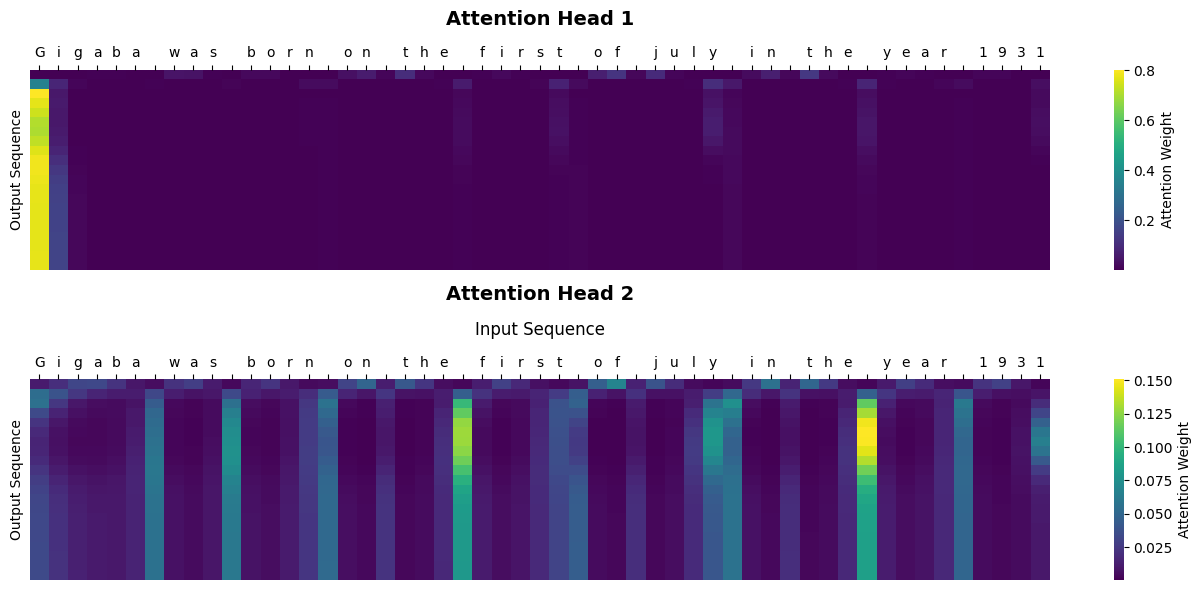

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# text = input("Enter text: ")
text = "Gigaba was born on the first of july in the year 1931"

model.eval()

encoded = encode_input(text)
input_tensor = torch.tensor([encoded], dtype=torch.long).to(device)

with torch.no_grad():
    logits, attn = model(input_tensor, target=None)

pred_ids = logits.argmax(-1)[0].cpu().tolist()
chars = []
for i in pred_ids:
    if i == output_stoi[EOS]:
        break

    if i not in (output_stoi[PAD], output_stoi[SOS]):
        chars.append(output_itos[i])

output = "".join(chars)

print(f"\nPredicted Output: {output}")

attn_tensor = attn[0].cpu().numpy()

out_len = len(chars)
in_len = len(text)

num_heads = attn_tensor.shape[1]
# create a vertical stack of subplots for each head
fig, axes = plt.subplots(num_heads, 1, figsize=(max(10, in_len * 0.25), max(3, out_len * 0.3) * num_heads))

# if num_heads is 1, axes isn't an array, so we wrap it in a list for the loop
if num_heads == 1:
    axes = [axes]

for h in range(num_heads):
    # extract attention for this specific head and trim out the <pad> tokens
    head_attn = attn_tensor[:, h, :in_len]
    ax = sns.heatmap(head_attn,
                xticklabels=list(text),
                yticklabels=list(output),
                cmap="viridis",
                cbar_kws={'label': 'Attention Weight'},
                ax=axes[h])

    # move the X-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # keep labels flat for readability
    for tick in ax.get_xticklabels():
        tick.set_rotation(0)
    for tick in ax.get_yticklabels():
        tick.set_rotation(0)

    axes[h].set_title(f"Attention Head {h + 1}", pad=15, fontweight='bold', fontsize=14)
    axes[h].set_ylabel("Output Sequence")

axes[-1].set_xlabel("Input Sequence", labelpad=15, fontsize=12)
plt.tight_layout()
plt.show()